# Calderon's Problem PlayGround

## Direct problem - forward finite differences solver

In [7]:
# filename: codebase/fdm_forward_solver.py
import os
import time
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set plotting style
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['text.usetex'] = False

### Generate the data

In [8]:
class FDMForwardSolver:
    """
    A Finite Difference Method (FDM) solver for the 2D Calderon's problem.

    This class solves the elliptic PDE nabla . (gamma * nabla u) = 0 on a
    square domain [0, 1] x [0, 1] with Dirichlet boundary conditions.
    """

    def __init__(self, N):
        """
        Initializes the FDM solver.

        Args:
            N (int): The number of grid points in each dimension.
        """
        self.N = N
        self.h = 1.0 / (N - 1)
        self.x = np.linspace(0, 1, N)
        self.y = np.linspace(0, 1, N)
        self.xx, self.yy = np.meshgrid(self.x, self.y)
        self.boundary_info = self.get_boundary_info()

    def get_boundary_info(self):
        """
        Identifies boundary nodes, coordinates, and normal vectors.

        Returns:
            dict: A dictionary containing:
                'indices': 1D indices of boundary nodes.
                'coords': (x, y) coordinates of boundary nodes.
                'normals': (nx, ny) normal vectors for each boundary node.
        """
        indices = []
        coords = []
        normals = []
        is_boundary = np.zeros((self.N, self.N), dtype=bool)

        for i in range(self.N):
            for j in range(self.N):
                is_bnd = False
                normal = [0, 0]
                if i == 0:  # Bottom
                    is_bnd = True
                    normal[1] = -1.0
                if i == self.N - 1:  # Top
                    is_bnd = True
                    normal[1] = 1.0
                if j == 0:  # Left
                    is_bnd = True
                    normal[0] = -1.0
                if j == self.N - 1:  # Right
                    is_bnd = True
                    normal[0] = 1.0

                if is_bnd:
                    idx_1d = i * self.N + j
                    indices.append(idx_1d)
                    coords.append((self.x[j], self.y[i]))
                    # Normalize the normal vector in case of corners
                    norm_len = np.sqrt(normal[0]**2 + normal[1]**2)
                    normals.append((normal[0]/norm_len, normal[1]/norm_len))
                    is_boundary[i, j] = True

        # Ensure unique nodes for corners
        unique_indices, unique_idx_map = np.unique(indices, return_index=True)
        
        return {
            'indices': unique_indices,
            'coords': np.array(coords)[unique_idx_map],
            'normals': np.array(normals)[unique_idx_map],
            'mask': is_boundary
        }


    def _assemble_system(self, gamma):
        """
        Assembles the sparse matrix A for the linear system Au=b.

        Args:
            gamma (np.ndarray): A N x N array of conductivity values.

        Returns:
            scipy.sparse.csc_matrix: The assembled sparse matrix A.
        """
        num_nodes = self.N * self.N
        A = sp.lil_matrix((num_nodes, num_nodes))
        h2 = self.h * self.h

        for i in range(1, self.N - 1):
            for j in range(1, self.N - 1):
                p = i * self.N + j

                # Harmonic mean for conductivity at interfaces
                gamma_E = 2 * gamma[i, j] * gamma[i, j + 1] / (gamma[i, j] + gamma[i, j + 1])
                gamma_W = 2 * gamma[i, j] * gamma[i, j - 1] / (gamma[i, j] + gamma[i, j - 1])
                gamma_N = 2 * gamma[i, j] * gamma[i + 1, j] / (gamma[i, j] + gamma[i + 1, j])
                gamma_S = 2 * gamma[i, j] * gamma[i - 1, j] / (gamma[i, j] + gamma[i - 1, j])

                A[p, p] = -(gamma_E + gamma_W + gamma_N + gamma_S) / h2
                A[p, p + 1] = gamma_E / h2  # East
                A[p, p - 1] = gamma_W / h2  # West
                A[p, p + self.N] = gamma_N / h2  # North
                A[p, p - self.N] = gamma_S / h2  # South

        return A.tocsc()

    def solve(self, gamma, boundary_values):
        """
        Solves the forward problem for a given gamma and boundary conditions.

        Args:
            gamma (np.ndarray): The N x N conductivity map.
            boundary_values (dict): A dictionary mapping 1D boundary indices
                                    to potential values.

        Returns:
            np.ndarray: A N x N array of the potential u.
        """
        num_nodes = self.N * self.N
        A = self._assemble_system(gamma)
        b = np.zeros(num_nodes)

        # Apply Dirichlet boundary conditions
        for idx, val in boundary_values.items():
            A[idx, :] = 0
            A[idx, idx] = 1
            b[idx] = val

        u_flat = spsolve(A, b)
        return u_flat.reshape((self.N, self.N))

    def compute_normal_current(self, u, gamma):
        """
        Computes the normal current density J = gamma * du/dn on the boundary.

        Args:
            u (np.ndarray): The N x N potential field.
            gamma (np.ndarray): The N x N conductivity map.

        Returns:
            np.ndarray: A 1D array of normal current densities at boundary points.
        """
        bnd_indices = self.boundary_info['indices']
        bnd_normals = self.boundary_info['normals']
        bnd_coords_map = {tuple(self.boundary_info['coords'][i]): i for i in range(len(bnd_indices))}
        
        J = np.zeros(len(bnd_indices))
        
        for i in range(self.N):
            for j in range(self.N):
                if not self.boundary_info['mask'][i, j]:
                    continue

                coord_tuple = (self.x[j], self.y[i])
                if coord_tuple not in bnd_coords_map:
                    continue
                
                map_idx = bnd_coords_map[coord_tuple]
                nx, ny = bnd_normals[map_idx]
                
                # Compute gradients using second-order one-sided differences
                du_dx = 0.0
                du_dy = 0.0

                # Gradient in x
                if j == 0:  # Left boundary, forward difference
                    du_dx = (-3 * u[i, 0] + 4 * u[i, 1] - u[i, 2]) / (2 * self.h)
                elif j == self.N - 1:  # Right boundary, backward difference
                    du_dx = (3 * u[i, -1] - 4 * u[i, -2] + u[i, -3]) / (2 * self.h)
                else: # Interior point for x-gradient (corners on y-boundary)
                    du_dx = (u[i, j + 1] - u[i, j - 1]) / (2 * self.h)

                # Gradient in y
                if i == 0:  # Bottom boundary, forward difference
                    du_dy = (-3 * u[0, j] + 4 * u[1, j] - u[2, j]) / (2 * self.h)
                elif i == self.N - 1:  # Top boundary, backward difference
                    du_dy = (3 * u[-1, j] - 4 * u[-2, j] + u[-3, j]) / (2 * self.h)
                else: # Interior point for y-gradient (corners on x-boundary)
                    du_dy = (u[i + 1, j] - u[i - 1, j]) / (2 * self.h)

                du_dn = du_dx * nx + du_dy * ny
                J[map_idx] = gamma[i, j] * du_dn
                
        return J




def get_gamma_two_inclusions(N):
    """
    Two non-overlapping circular inclusions:
    - Inclusion 1 at center (0.5, 0.5), radius 0.2
    - Inclusion 2 shifted to (0.8, 0.2), radius 0.15
    """
    gamma = np.ones((N, N))

    # Circle parameters
    cx1, cy1, r1, val1 = 0.5, 0.5, 0.2, 2.0
    cx2, cy2, r2, val2 = 0.8, 0.2, 0.15, 3.0

    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)

    mask1 = (xx - cx1)**2 + (yy - cy1)**2 < r1**2
    mask2 = (xx - cx2)**2 + (yy - cy2)**2 < r2**2

    gamma[mask1] = val1
    gamma[mask2] = val2

    return gamma



def get_gamma_single_inclusion(N):
    """Generates a conductivity map with a single circular inclusion."""
    gamma = np.ones((N, N))
    center_x, center_y, radius = 0.5, 0.5, 0.2
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    mask = (xx - center_x)**2 + (yy - center_y)**2 < radius**2
    gamma[mask] = 2.0
    return gamma

# def get_gamma_gaussian(N):
#     """Generates a conductivity map with a 2D Gaussian inclusion."""
#     gamma = np.ones((N, N))
#     center_x, center_y, radius = 0.5, 0.5, 0.3
#     x = np.linspace(0, 1, N)
#     y = np.linspace(0, 1, N)
#     xx, yy = np.meshgrid(x, y)
    
#     sigma = radius
#     gaussian = np.exp(-((xx - center_x)**2 + (yy - center_y)**2) / (2 * sigma**2))
    
#     # Scale so that max = 2.0 (background=1, peak=2)
#     gamma += gaussian  # background 1 + bump [0..1]
    
#     return gamma

def get_gamma_radial_sine(N, freq=1.9, amplitude=1.0):
    """
    Generates a radially symmetric conductivity map with sine variation.
    
    Parameters
    ----------
    N : int
        Grid size (N x N).
    freq : float
        Frequency of the sine oscillation in radial direction.
    amplitude : float
        Amplitude of oscillation.
    """
    gamma = np.ones((N, N))
    center_x, center_y = 0.5, 0.5
    
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)


    
#     r = np.sqrt((xx - center_x)**2 + (yy - center_y)**2)
    
#     gamma += amplitude * np.sin(2 * np.pi * freq * r)
    
#     return gamma


# def get_gamma_multiple_inclusions(N):
#     """Generates a conductivity map with two circular inclusions."""
#     gamma = np.ones((N, N))
#     x = np.linspace(0, 1, N)
#     y = np.linspace(0, 1, N)
#     xx, yy = np.meshgrid(x, y)
#     mask1 = (xx - 0.3)**2 + (yy - 0.6)**2 < 0.15**2
#     gamma[mask1] = 2.0
#     mask2 = (xx - 0.7)**2 + (yy - 0.3)**2 < 0.2**2
#     gamma[mask2] = 0.5
#     return gamma

# def get_gamma_checkerboard(N):
#     """Generates a checkerboard conductivity map."""
#     gamma = np.ones((N, N))
#     x = np.linspace(0, 1, N, endpoint = False)
#     y = np.linspace(0, 1, N, endpoint = False)
#     xx, yy = np.meshgrid(x, y)
#     checker = (np.floor(xx * 4) + np.floor(yy * 4)) % 2
#     gamma[checker == 1] = 2.0
#     return gamma

# #INVERTED GAUSSIAN WELL

# def get_gamma_inverted_gaussian(N, depth=0.5):
#     """
#     Generates a conductivity map with an inverted 2D Gaussian 'well'.
    
#     - Background is 1.0 far from the center.
#     - At the center, gamma = 1 - depth (so choose 0 < depth < 1 to keep positivity).
    
#     Parameters
#     ----------
#     N : int
#         Grid size (N x N).
#     depth : float
#         How deep the well is, relative to the background (0 < depth < 1).
#         depth = 0.5 -> center value = 0.5, sides ~ 1.0
#     """
#     if not (0 < depth < 1):
#         raise ValueError("depth must be in (0, 1) to keep gamma strictly positive.")
    
#     gamma = np.ones((N, N))
#     center_x, center_y, radius = 0.73, 0.28, 0.17
    
#     x = np.linspace(0, 1, N)
#     y = np.linspace(0, 1, N)
#     xx, yy = np.meshgrid(x, y)
    
#     sigma = radius
#     gaussian = np.exp(-((xx - center_x)**2 + (yy - center_y)**2) / (2 * sigma**2))
    
#     # Inverted Gaussian: minimum at center, tends to 1 away from center
#     gamma -= depth * gaussian   # center = 1 - depth, outside ~ 1
    
#     return gamma



# def get_gamma_horizontal_split(N, gamma_top=2.0, gamma_bottom=0.5):
#     """Generates a conductivity map split horizontally with two constant values."""
#     gamma = np.ones((N, N))
#     gamma[:N//2, :] = gamma_bottom  # Bottom half
#     gamma[N//2:, :] = gamma_top     # Top half
#     return gamma

# --- Ricker wavelet definition ---
def ricker_wavelet(x, x0=0.5, a=10.0):
    """1D Ricker wavelet centered at x0 with width parameter a."""
    return (1 - 2 * (np.pi * a * (x - x0))**2) * np.exp(-(np.pi * a * (x - x0))**2)

def ricker_wavelet_zero_endpoints(x, x0=0.5, a=10.0):
    """Ricker wavelet that is exactly zero at x=0 and x=1."""
    base = (1 - 2 * (np.pi * a * (x - x0))**2) * np.exp(-(np.pi * a * (x - x0))**2)
    window = np.sin(np.pi * x)  # smooth tapering to zero at ends
    return base * window

def add_wavelets_on_side(
    f,
    side_name,
    sides,
    bnd_coords,
    centers,
    widths,
    amplitudes
):
    """
    Add one or more Ricker wavelets to a given side into the BC vector f.

    f          : 1D array of size len(bnd_coords) (modified in-place).
    side_name  : 'bottom' | 'top' | 'left' | 'right'.
    sides      : dict side_name -> indices of bnd_coords on that side.
    bnd_coords : (M, 2) array of boundary coordinates.
    centers    : iterable of x0 positions in [0,1] for this side.
    widths     : iterable of 'a' parameters.
    amplitudes : iterable of amplitudes.
    """
    idx = sides[side_name]
    if side_name in ["bottom", "top"]:
        coord = bnd_coords[idx, 0]  # vary along x
    else:
        coord = bnd_coords[idx, 1]  # vary along y

    total = np.zeros_like(coord)
    for x0 in centers:
        for a in widths:
            for amp in amplitudes:
                total += amp * ricker_wavelet_zero_endpoints(coord, x0=x0, a=a)

    f[idx] += total




def generate_dtn_data_random(
    case_name,
    gamma_true,
    N,
    K=100,                         # number of random BCs
    saving_path=None,
    max_wavelets_per_side=3,       # upper bound on wavelets per active side
    center_range=(0.2, 0.8),       # where along the side we can place centers
    width_range=(0.3, 3),        # random a in this range, IMPORTANT, 
                                        ###a = 2.5 → width ~ 50%
                                        ###a = 6.5 → width ~ 20%
                                        ###a = 13 → width ~ 10%       a goes like 1 / desired width
                                        ###a = 26 → width ~ 5%

    amplitude_range=(0.5, 4.5),    # random amplitude in this range
    include_patterns=(1, 2, 3, 4), # 1=one side active, 2=two sides, ...
    rng_seed=None                  # for reproducibility if you want
):
    """
    Generates and saves DtN data with RANDOM Ricker-wavelet boundary conditions.

    For each boundary condition:
      - randomly choose a pattern (how many sides are active),
      - randomly choose which sides,
      - for each active side:
          * random number of wavelets (1..max_wavelets_per_side)
          * random centers along the side within center_range
          * random width a within width_range
          * random amplitude within amplitude_range

    Returns:
        filename, u_example, f_example, J_example
    """
    print(f"--- Starting RANDOM data generation for case: {case_name} ---")

    solver = FDMForwardSolver(N)
    bnd_info = solver.boundary_info
    bnd_indices = bnd_info["indices"]
    bnd_coords = bnd_info["coords"]

    # RNG
    rng = np.random.default_rng(rng_seed)

    # Group boundary indices by side
    tol = 1e-12
    sides = {
        "bottom": np.where(np.abs(bnd_coords[:, 1]) < tol)[0],
        "top":    np.where(np.abs(bnd_coords[:, 1] - 1) < tol)[0],
        "left":   np.where(np.abs(bnd_coords[:, 0]) < tol)[0],
        "right":  np.where(np.abs(bnd_coords[:, 0] - 1) < tol)[0],
    }
    side_list = ["bottom", "right", "top", "left"]

    boundary_potentials = []
    clean_currents = []
    induced_potentials = []

    all_fks = []

    # --------------------- RANDOM BC GENERATION ---------------------
    for k in range(K):
        f = np.zeros(len(bnd_coords))

        # Choose how many sides are active this time (pattern)
        pattern = int(rng.choice(include_patterns))  # e.g. 1,2,3,4
        pattern = max(1, min(pattern, 5))            # clamp just in case

        # Pick "pattern" distinct sides
        active_sides = list(rng.choice(side_list, size=pattern, replace=False))

        for side in active_sides:
            # Random number of wavelets on this side
            n_wv = int(rng.integers(1, max_wavelets_per_side + 1))

            # Random centers along the side
            centers = rng.uniform(center_range[0], center_range[1], size=n_wv)

            # One random width and amplitude for this side
            a = float(rng.uniform(width_range[0], width_range[1]))
            #amp = float(rng.uniform(amplitude_range[0], amplitude_range[1]))
            # Use both positive and negative amplitudes
            base_amp = float(rng.uniform(amplitude_range[0], amplitude_range[1]))
            sign = rng.choice([-1.0, 1.0])
            amp = sign * base_amp

            add_wavelets_on_side(
                f,
                side,
                sides,
                bnd_coords,
                centers=centers,
                widths=[a],
                amplitudes=[amp],
            )

        all_fks.append(f)

    print(f"Generated {len(all_fks)} random boundary conditions.")

    # --------------------- SOLVE FOR ALL BCs ---------------------
    start_time = time.time()
    for k, f_k in enumerate(all_fks):
        boundary_values = {idx: val for idx, val in zip(bnd_indices, f_k)}
        u_k = solver.solve(gamma_true, boundary_values)
        J_k = solver.compute_normal_current(u_k, gamma_true)

        boundary_potentials.append(f_k)
        clean_currents.append(J_k)
        induced_potentials.append(u_k)

        if (k + 1) % 10 == 0 or (k + 1) == K:
            print(f"Solved {k + 1}/{K} random boundary conditions...")

    boundary_potentials = np.array(boundary_potentials)
    clean_currents = np.array(clean_currents)

    # --------------------- SAVE DATA ---------------------
    if saving_path is None:
        data_folder = "data_wavelet_random"
    else:
        data_folder = saving_path
    os.makedirs(data_folder, exist_ok=True)

    filename = os.path.join(data_folder, f"dtn_data_{case_name}.npz")
    np.savez_compressed(
        filename,
        gamma_true=gamma_true,
        boundary_coords=bnd_coords,
        boundary_potentials=boundary_potentials,
        clean_currents=clean_currents,
        induced_potentials=induced_potentials,
        grid_N=N,
        num_bcs=K,
    )

    end_time = time.time()
    print(f"Random data generation complete in {round(end_time - start_time, 2)} s")
    print(f"Saved to: {filename}")

    return filename, induced_potentials[0], boundary_potentials[0], clean_currents[0]




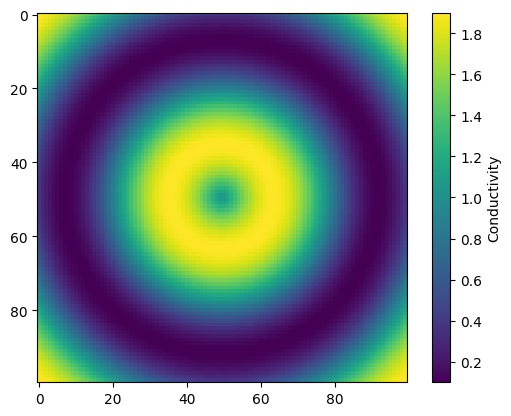

In [9]:
def get_gamma_radial_sine(N, freq=2, amplitude=0.9):
    """
    Generates a radially symmetric conductivity map with sine variation.
    
    Parameters
    ----------
    N : int
        Grid size (N x N).
    freq : float
        Frequency of the sine oscillation in radial direction.
    amplitude : float
        Amplitude of oscillation.
    """
    gamma = np.ones((N, N))
    center_x, center_y = 0.5, 0.5
    
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    
    r = np.sqrt((xx - center_x)**2 + (yy - center_y)**2)
    
    gamma += amplitude * np.sin(2 * np.pi * freq * r)
    
    return gamma
plt.figure()
N = 100
gamma = get_gamma_radial_sine(N, freq=1.75, amplitude=0.9)
plt.imshow(gamma, cmap='viridis')
plt.colorbar(label='Conductivity')

In [10]:

def main(N,K, saving_path=None):
    """Main function to generate all datasets and plots."""
    N = N  # Grid size
    K = K   # Number of boundary conditions
    if saving_path is None:
        saving_path = "data"
    
    cases = {
        #"two_inclusions": get_gamma_two_inclusions(N),
        # "gaussian_inclusion": get_gamma_gaussian(N),
        "radially_sym_sine": get_gamma_radial_sine(N, freq=1.75, amplitude=0.5),
        # "multiple_inclusions": get_gamma_multiple_inclusions(N),
        #"checkerboard_wavelets": get_gamma_checkerboard(N),
        #"horizontal_split_wavelets": get_gamma_horizontal_split(N, gamma_top=2.0, gamma_bottom=0.5)
    }
    
    for name, gamma_true in cases.items():
        filepath, u_ex, f_ex, J_ex = generate_dtn_data_random(name, gamma_true, N, K, saving_path=saving_path)
        
        # Plotting
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Plot 1: Ground Truth Gamma
        im0 = axes[0].imshow(gamma_true, origin='lower', extent=[0, 1, 0, 1], cmap='viridis')
        axes[0].set_title("Ground Truth Conductivity (gamma)")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("y")
        fig.colorbar(im0, ax=axes[0], orientation='vertical')
        
        # Plot 2: Example Potential Solution u_k
        im1 = axes[1].imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
        axes[1].set_title("Example Potential Field u_0(x,y)")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("y")
        fig.colorbar(im1, ax=axes[1], orientation='vertical')
        
        # Plot 3: Example DtN data pair (f_k, J_k)
        bnd_info = FDMForwardSolver(N).boundary_info
        bnd_coords = bnd_info['coords']
        # Create a perimeter-like coordinate for plotting
        perimeter = np.zeros(len(bnd_coords))
        for i in range(1, len(bnd_coords)):
            perimeter[i] = perimeter[i-1] + np.linalg.norm(bnd_coords[i] - bnd_coords[i-1])
        
        axes[2].plot(perimeter, f_ex, 'b-', label='Potential f_0')
        ax2_twin = axes[2].twinx()
        ax2_twin.plot(perimeter, J_ex, 'r-', label='Current J_0')
        axes[2].set_title("Example DtN Pair on Boundary")
        axes[2].set_xlabel("Perimeter along Boundary")
        axes[2].set_ylabel("Potential (V)", color='b')
        ax2_twin.set_ylabel("Current Density (A/m^2)", color='r')
        axes[2].grid(True)
        
        fig.tight_layout()
        
        plot_filename = os.path.join("data", "plot_summary_" + name + "_" + str(int(time.time())) + ".png")
        plt.savefig(plot_filename, dpi=300)
        print("\nSummary plot saved to " + plot_filename)
        print("Plot description: Shows the ground truth conductivity, a sample potential solution, and an example DtN pair for the '" + name + "' case.")
        plt.close(fig)
        print("\n" + "="*50 + "\n")


## Combine BC $\{u_k(x),\,f_k(x),\,J_k(x)\}$ for the same ground truth conducticity $\gamma(x)$

### Gaussian (wide)

In [11]:
# data_trig = np.load(f"{os.getcwd()}/data_pablo_trial_4.5_gaussian_wider/dtn_data_gaussian_inclusion.npz")
# data_wavelets = np.load(f"{os.getcwd()}/data_pablo_more_wavelets_trial_3/dtn_data_gaussian_inclusion.npz")

# gamma_true_trig = data_trig["gamma_true"]             # (N, N)
# bnd_coords_trig = data_trig["boundary_coords"]        # (num_boundary_points, 2)
# u_all_trig = data_trig["induced_potentials"]          # (K, N, N)
# f_all_trig = data_trig["boundary_potentials"]         # (K, num_boundary_points)
# J_all_trig = data_trig["clean_currents"]              # (K, num_boundary_points)
# N_trig = int(data_trig["grid_N"])
# K_trig = int(data_trig["num_bcs"])

# gamma_true_wavelets = data_wavelets["gamma_true"]     # (N, N)
# bnd_coords_wavelets = data_wavelets["boundary_coords"]
# u_all_wavelets = data_wavelets["induced_potentials"]
# f_all_wavelets = data_wavelets["boundary_potentials"]
# J_all_wavelets = data_wavelets["clean_currents"]
# N_wavelets = int(data_wavelets["grid_N"])
# K_wavelets = int(data_wavelets["num_bcs"])


In [12]:
# N = N_trig  # assuming N_trig == N_wavelets
# K = K_trig + K_wavelets
# u_all = np.concatenate((u_all_trig, u_all_wavelets), axis=0)
# f_all = np.concatenate((f_all_trig, f_all_wavelets), axis=0)
# J_all = np.concatenate((J_all_trig, J_all_wavelets), axis=0)

# gamma_true = gamma_true_trig  # or gamma_true_wavelets if preferred
# bnd_coords = bnd_coords_trig  # or bnd_coords_wavelets

# print("Shapes after concatenation:")
# print("u_all:", u_all.shape)
# print("f_all:", f_all.shape)
# print("J_all:", J_all.shape)
# print("gamma_true:", gamma_true.shape)
# print("bnd_coords:", bnd_coords.shape)
# print("N:", N, "K:", K)


In [13]:
N=64
K=6
saving_path="data_radially_sym_sine_BC_wavelets_test"

In [14]:
main(N=N, K=K, saving_path=saving_path)

--- Starting RANDOM data generation for case: radially_sym_sine ---
Generated 6 random boundary conditions.


c:\Users\alika\.pyenv\pyenv-win\versions\3.12.9\Lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


Solved 6/6 random boundary conditions...
Random data generation complete in 27.62 s
Saved to: data_radially_sym_sine_BC_wavelets_test\dtn_data_radially_sym_sine.npz

Summary plot saved to data\plot_summary_radially_sym_sine_1765299218.png
Plot description: Shows the ground truth conductivity, a sample potential solution, and an example DtN pair for the 'radially_sym_sine' case.




In [15]:
# Load the compressed npz file
# data = np.load(f"data_pablo_trial/dtn_data_single_inclusion.npz")

data = np.load(f"{saving_path}/dtn_data_radially_sym_sine.npz")

# See what keys are inside
print("Keys in file:")
for key in data.keys():
    print(key)

Keys in file:
gamma_true
boundary_coords
boundary_potentials
clean_currents
induced_potentials
grid_N
num_bcs


In [16]:
gamma_true = data["gamma_true"]          # (N, N) conductivity map
bnd_coords = data["boundary_coords"]     # (num_boundary_points, 2)
u_all = data["induced_potentials"]      # (K, N, N)
f_all = data["boundary_potentials"]      # (K, num_boundary_points)
J_all = data["clean_currents"]           # (K, num_boundary_points)
# J_noisy1 = data["noisy_currents_1pct"]   # same shape, noisy
# J_noisy5 = data["noisy_currents_5pct"]   # same shape, noisy
N = int(data["grid_N"])
K = int(data["num_bcs"])


In [17]:
f_all.shape

(6, 252)

(64, 64)


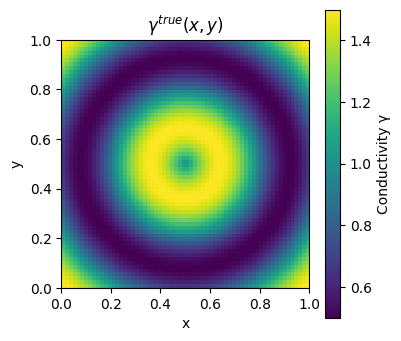

In [18]:
print(gamma_true.shape)


fig = plt.figure(figsize=(4,4))
plt.imshow(gamma_true, origin='lower', extent=[0,1,0,1], cmap="viridis")
plt.colorbar(label="Conductivity γ")
plt.title(r"$\gamma^{true}(x,y)$")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

u_all shape (6, 64, 64)


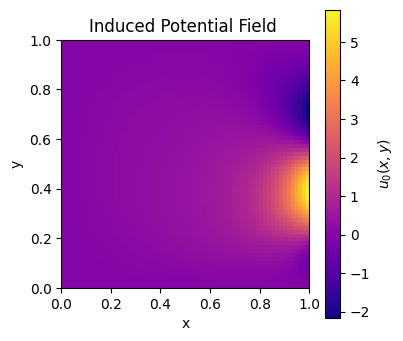

In [19]:
k=0

print('u_all shape', u_all.shape)

u_ex = u_all[k,:,:]

fig = plt.figure(figsize=(4,4))
im1 = plt.imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
plt.title(r"Induced Potential Field ")
plt.xlabel("x")
plt.ylabel("y")
fig.colorbar(im1, label=r'$u_0(x,y)$', orientation='vertical')
plt.show()

(0.0, 255.0)

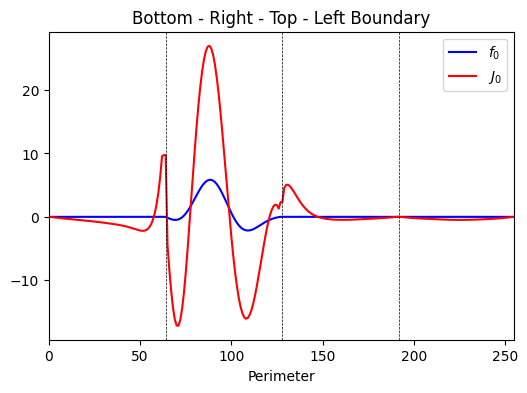

In [20]:
k = 0

######### CHAT GPT ################

x, y = bnd_coords[:,0], bnd_coords[:,1]

# Identify edges
tol = 1e-12
bottom_idx = np.where(np.abs(y - 0.0) < tol)[0]
top_idx    = np.where(np.abs(y - 1.0) < tol)[0]
left_idx   = np.where(np.abs(x - 0.0) < tol)[0]
right_idx  = np.where(np.abs(x - 1.0) < tol)[0]

# Sort along each edge
bottom_idx = bottom_idx[np.argsort(x[bottom_idx])]         # left→right
top_idx    = top_idx[np.argsort(x[top_idx])][::-1]         # right→left
right_idx  = right_idx[np.argsort(y[right_idx])]           # bottom→top
left_idx   = left_idx[np.argsort(y[left_idx])][::-1]       # top→bottom

# Concatenate perimeter
perimeter_idx = np.concatenate([bottom_idx, right_idx, top_idx, left_idx])

# Reorder f and J consistently
f_true = f_all[k, perimeter_idx]
J_true = J_all[k, perimeter_idx]

afine = np.arange(4*(N))


#################

fig = plt.figure(figsize=(6,4))
plt.plot(afine, f_true, 'b-', label=r"$f_0$")
plt.plot(afine, J_true, 'r-', label=r"$J_0$")
for i in range(1,4):
    plt.axvline(i*N, color='k', linestyle='--', linewidth=0.5)
plt.xlabel('Perimeter')
plt.legend()
plt.title('Bottom - Right - Top - Left Boundary')

plt.xlim(left=0, right = 4*N-1)


# fig = plt.figure(figsize=(10,2))
# plt.scatter(left_true[:,1], f_left, color='b', s=20)
# plt.scatter(right_true[:-2,1], f_right[:-2], color='r', s=5)
# # plt.scatter(right_true[-1,1], f_right[-1], color='g', s=5)
# plt.show()

# fig = plt.figure(figsize=(4,4))
# plt.scatter(bottom[:,0], f_bottom, color='g', s=5)
# plt.scatter(top[:,0], f_top, color='m', s=5)

[0 1 2 3 4 5]


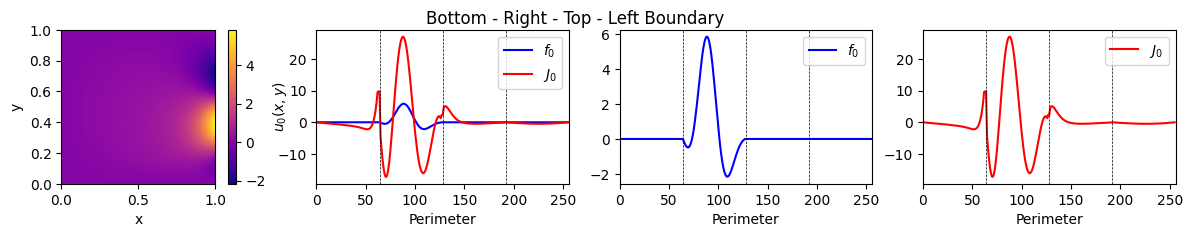

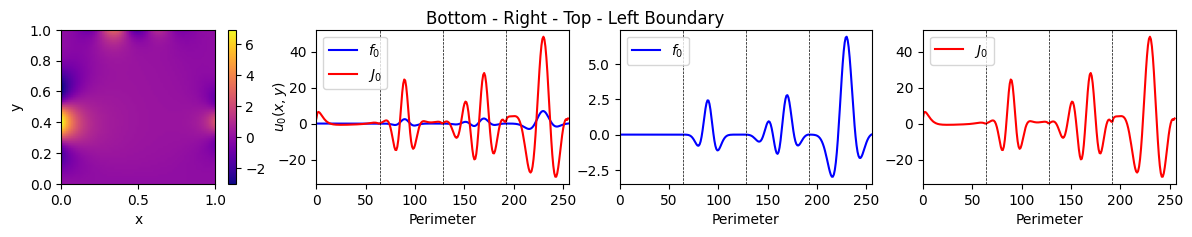

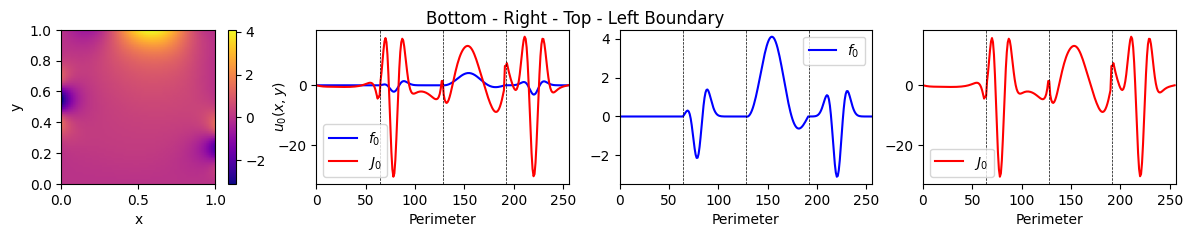

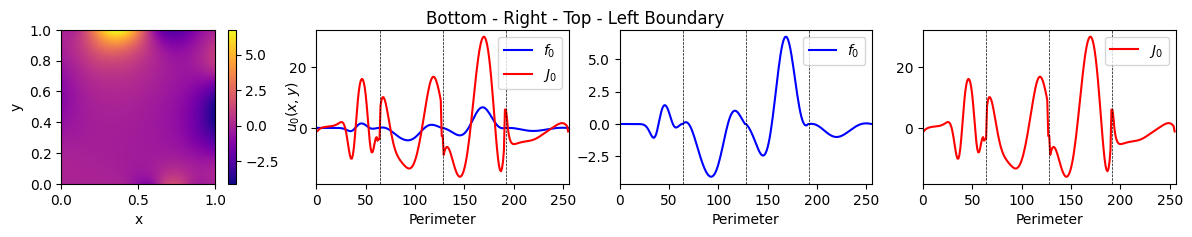

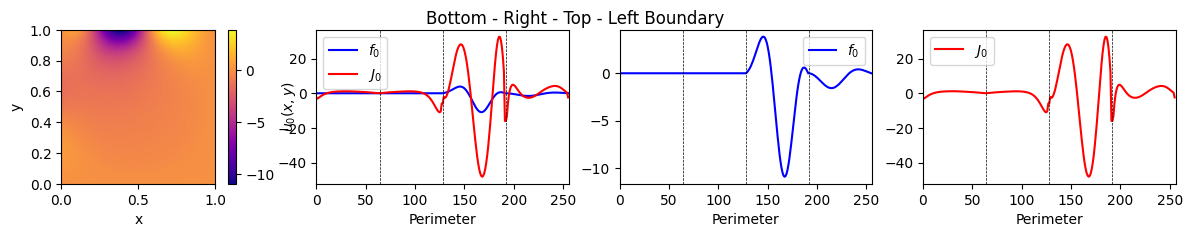

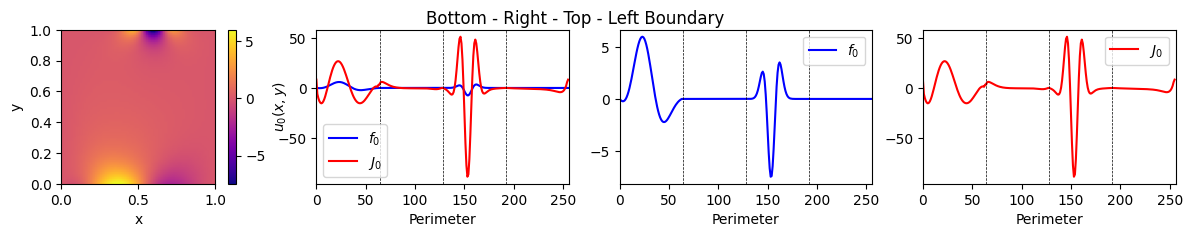

In [21]:
k_list=np.arange(K)
print(k_list)

for k in (k_list):

    f_true = f_all[k, perimeter_idx]
    J_true = J_all[k, perimeter_idx]

    u_ex = u_all[k,:,:]

    fig,ax = plt.subplots(1,4,figsize=(15,2))

    im1 = ax[0].imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")
    fig.colorbar(im1, ax=ax[0], orientation='vertical', label = r'$u_0(x,y)$')

    ax[1].plot(afine, f_true, 'b-', label=r"$f_0$")
    ax[1].plot(afine, J_true, 'r-', label=r"$J_0$")
    for i in range(1,4):
        ax[1].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[1].set_xlabel('Perimeter')
    ax[1].legend()
    ax[1].set_xlim(left=0, right=4*N)

    ax[2].plot(afine, f_true, 'b-', label=r"$f_0$")
    for i in range(1,4):
        ax[2].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[2].set_xlabel('Perimeter')
    ax[2].legend()
    ax[2].set_xlim(left=0, right=4*N)

    ax[3].plot(afine, J_true, 'r-', label=r"$J_0$")
    for i in range(1,4):
        ax[3].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[3].set_xlabel('Perimeter')
    ax[3].legend()
    ax[3].set_xlim(left=0, right=4*N)
    
    plt.suptitle('Bottom - Right - Top - Left Boundary')

    plt.show()


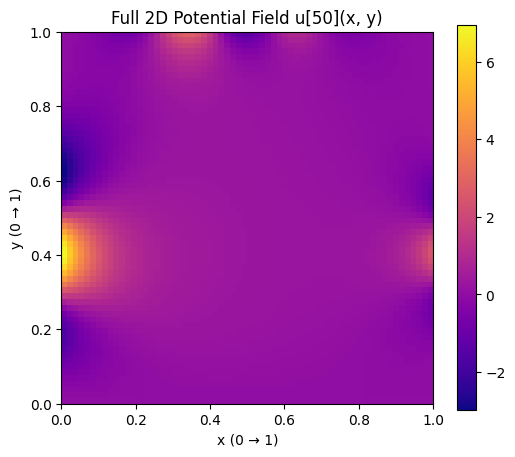

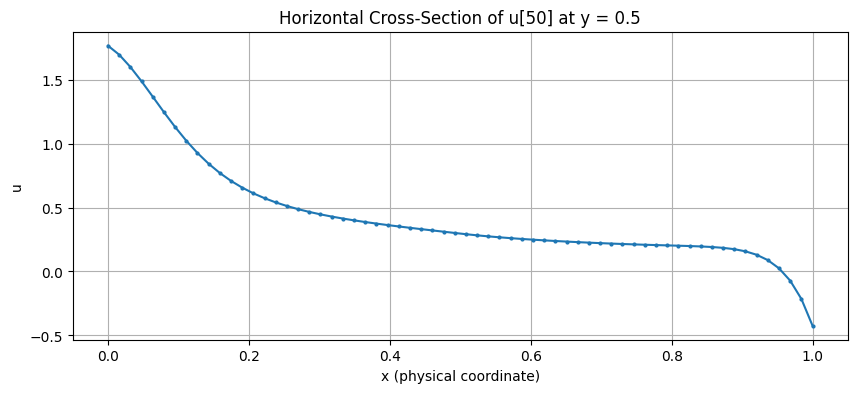

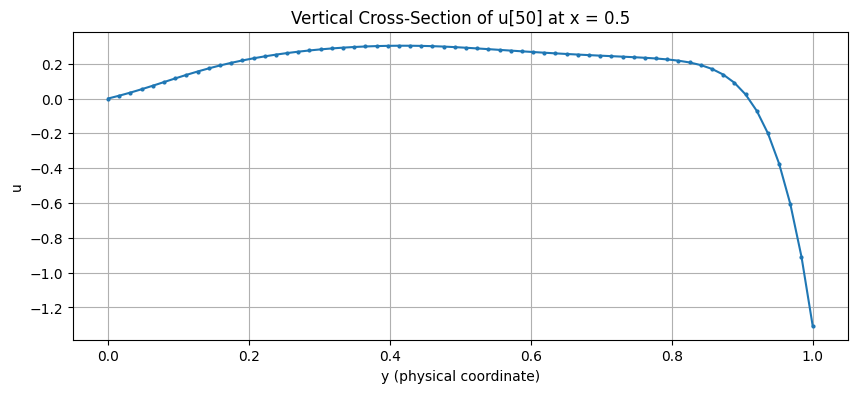

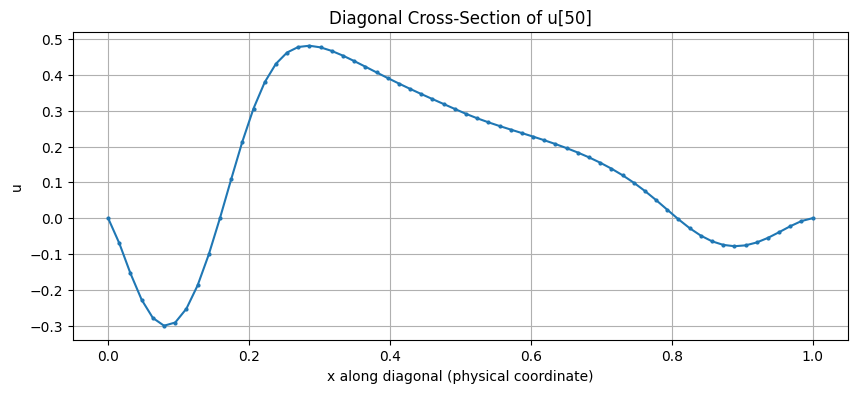

In [22]:
# Load all potentials
data = np.load(f"{saving_path}/dtn_data_radially_sym_sine.npz")
all_u = data["induced_potentials"]

# Pick the 50th solution
u = all_u[1]
N = u.shape[0]

x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)

# 0) Full 2D plot
plt.figure(figsize=(6,5))
plt.imshow(u, origin='lower', extent=[0,1,0,1], cmap='plasma')
plt.colorbar()
plt.title("Full 2D Potential Field u[50](x, y)")
plt.xlabel("x (0 → 1)")
plt.ylabel("y (0 → 1)")
plt.show()

# 1) Horizontal slice at y=0.5
mid_y = N // 2
plt.figure(figsize=(10,4))
plt.plot(x, u[mid_y, :], '-o', markersize=2)
plt.title("Horizontal Cross-Section of u[50] at y = 0.5")
plt.xlabel("x (physical coordinate)")
plt.ylabel("u")
plt.grid(True)
plt.show()

# 2) Vertical slice at x=0.5
mid_x = N // 2
plt.figure(figsize=(10,4))
plt.plot(y, u[:, mid_x], '-o', markersize=2)
plt.title("Vertical Cross-Section of u[50] at x = 0.5")
plt.xlabel("y (physical coordinate)")
plt.ylabel("u")
plt.grid(True)
plt.show()

# 3) Diagonal slice (y = x)
diag = np.diagonal(u)
plt.figure(figsize=(10,4))
plt.plot(x, diag, '-o', markersize=2)
plt.title("Diagonal Cross-Section of u[50]")
plt.xlabel("x along diagonal (physical coordinate)")
plt.ylabel("u")
plt.grid(True)
plt.show()


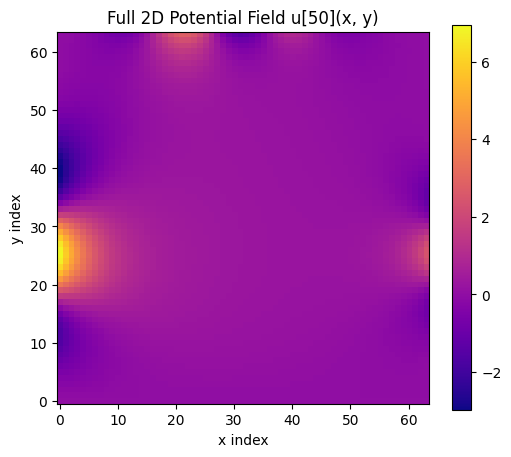

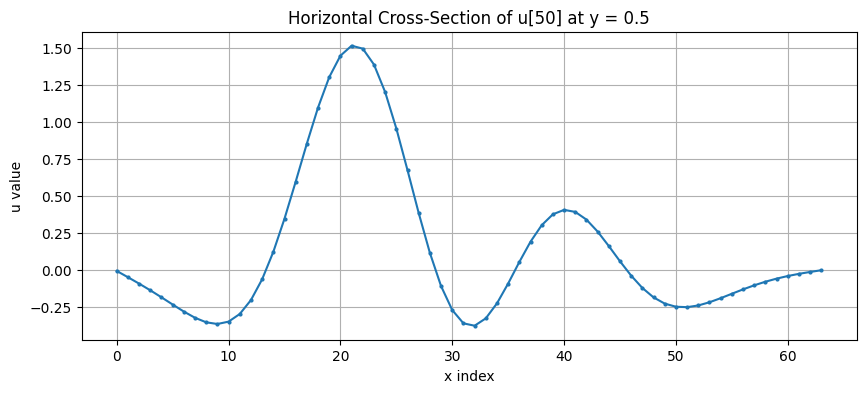

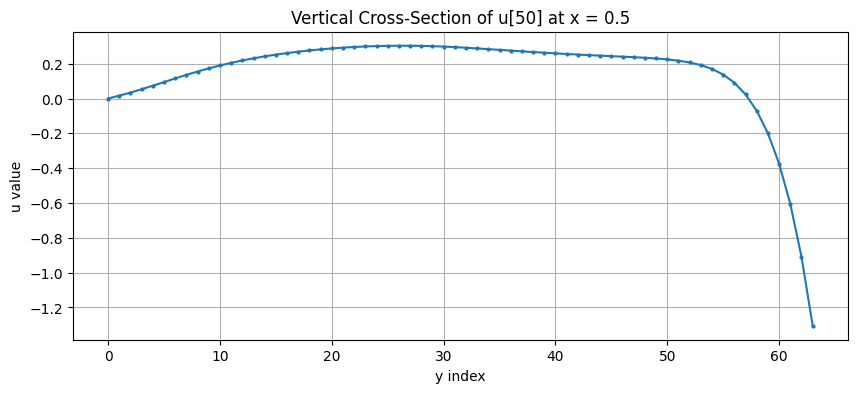

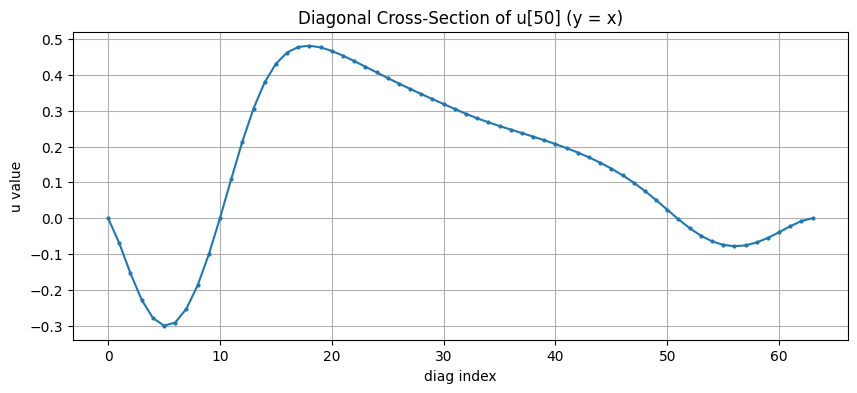

In [23]:
# Load all potentials
data = np.load(f"{saving_path}/dtn_data_radially_sym_sine.npz")
all_u = data["induced_potentials"]

# Pick the 50th u (index 50)
u = all_u[1]   # <<< HERE you choose which u you want

N = u.shape[0]

# -----------------------------------------------------
# 0) Plot the full 2D u[50] field
# -----------------------------------------------------
plt.figure(figsize=(6,5))
plt.imshow(u, origin='lower', cmap='plasma')
plt.colorbar()
plt.title("Full 2D Potential Field u[50](x, y)")
plt.xlabel("x index")
plt.ylabel("y index")
plt.show()

# -----------------------------------------------------
# 1) Horizontal cross-section at y = 0.5
# -----------------------------------------------------
mid_y = N // 2
plt.figure(figsize=(10,4))
plt.plot(u[60, :], '-o', markersize=2)
plt.title("Horizontal Cross-Section of u[50] at y = 0.5")
plt.xlabel("x index")
plt.ylabel("u value")
plt.grid(True)
plt.show()

# -----------------------------------------------------
# 2) Vertical cross-section at x = 0.5
# -----------------------------------------------------
mid_x = N // 2
plt.figure(figsize=(10,4))
plt.plot(u[:, mid_x], '-o', markersize=2)
plt.title("Vertical Cross-Section of u[50] at x = 0.5")
plt.xlabel("y index")
plt.ylabel("u value")
plt.grid(True)
plt.show()

# -----------------------------------------------------
# 3) Diagonal cross-section (y = x)
# -----------------------------------------------------
diag = np.diagonal(u)
plt.figure(figsize=(10,4))
plt.plot(diag, '-o', markersize=2)
plt.title("Diagonal Cross-Section of u[50] (y = x)")
plt.xlabel("diag index")
plt.ylabel("u value")
plt.grid(True)
plt.show()


Index for x0 = 6  (physical x = 0.09523809523809523 )
Index for y0 = 38  (physical y = 0.6031746031746031 )


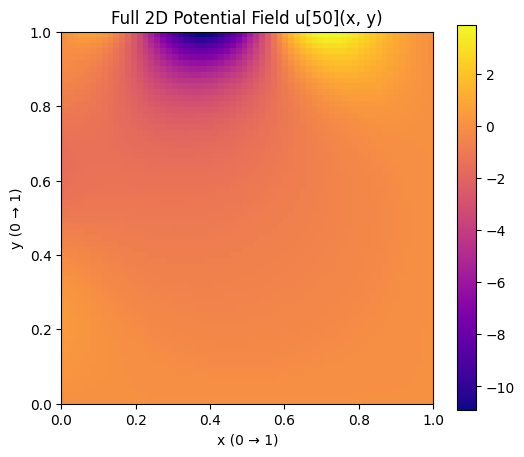

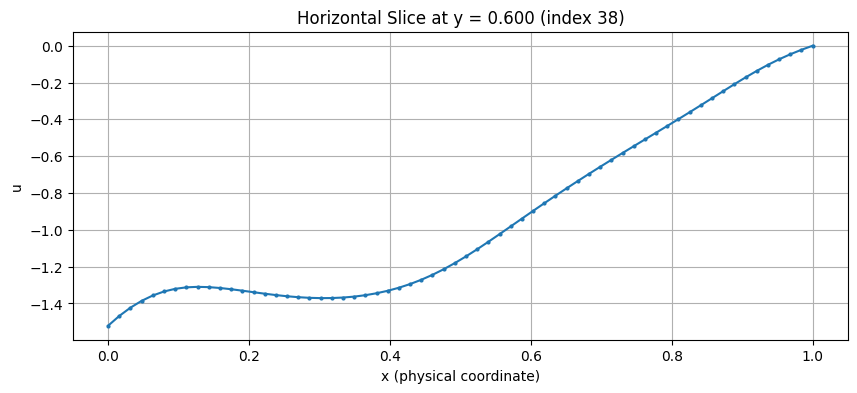

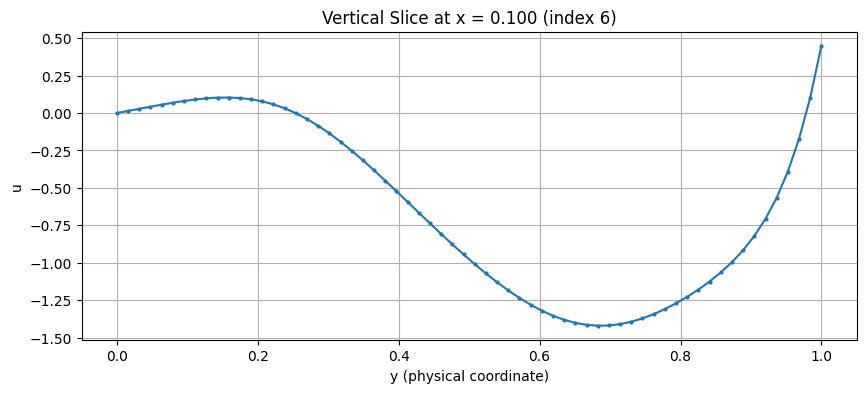

In [24]:
# Load potentials
data = np.load(f"{saving_path}/dtn_data_radially_sym_sine.npz")
all_u = data["induced_potentials"]
u = all_u[4]
N = u.shape[0]

x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)

# -------------------------------
# Choose slice locations (YOU SET THESE)
# -------------------------------
x0 = 0.1    # slice vertically at this x
y0 = 0.6    # slice horizontally at this y

# Find nearest grid indices
ix = np.argmin(np.abs(x - x0))
iy = np.argmin(np.abs(y - y0))

print("Index for x0 =", ix, " (physical x =", x[ix], ")")
print("Index for y0 =", iy, " (physical y =", y[iy], ")")

# 0) Full 2D plot
plt.figure(figsize=(6,5))
plt.imshow(u, origin='lower', extent=[0,1,0,1], cmap='plasma')
plt.colorbar()
plt.title("Full 2D Potential Field u[50](x, y)")
plt.xlabel("x (0 → 1)")
plt.ylabel("y (0 → 1)")
plt.show()

# --------------------------------
# 1) Horizontal slice at y = y0
# --------------------------------
plt.figure(figsize=(10,4))
plt.plot(x, u[iy, :], '-o', markersize=2)
plt.title(f"Horizontal Slice at y = {y0:.3f} (index {iy})")
plt.xlabel("x (physical coordinate)")
plt.ylabel("u")
plt.grid(True)
plt.show()

# --------------------------------
# 2) Vertical slice at x = x0
# --------------------------------
plt.figure(figsize=(10,4))
plt.plot(y, u[:, ix], '-o', markersize=2)
plt.title(f"Vertical Slice at x = {x0:.3f} (index {ix})")
plt.xlabel("y (physical coordinate)")
plt.ylabel("u")
plt.grid(True)
plt.show()
